# Ridge Regression

## Problem Statement
In this notebook, we will implement Ridge Regression using Python.

Ridge Regression is used to predict continuous numerical values.  
It is similar to Linear Regression, but it adds regularization to reduce overfitting.

## Dataset Used
We will use an Advertising Dataset to predict sales based on TV, Radio, and Newspaper advertising budget.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

## Dataset Loading
Now we will load the Diabetes dataset and convert it into a Pandas DataFrame.

In [2]:
data = {
    "TV": [230.1, 44.5, 17.2, 151.5, 180.8, 8.7, 57.5, 120.2, 199.8, 66.1],
    "Radio": [37.8, 39.3, 45.9, 41.3, 10.8, 48.9, 32.8, 19.6, 2.6, 5.8],
    "Newspaper": [69.2, 45.1, 69.3, 58.5, 58.4, 75.0, 23.5, 11.6, 21.2, 24.2],
    "Sales": [22.1, 10.4, 9.3, 18.5, 12.9, 7.2, 11.8, 13.2, 10.6, 8.6]
}

df = pd.DataFrame(data)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Exploratory Data Analysis

In this step, we will check:
- Dataset shape
- Missing values
- Data types
- Statistical summary
- Correlation
- Visualization

In [3]:
print("Dataset Shape:", df.shape)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nData Types:")
print(df.dtypes)

df.describe()

Dataset Shape: (442, 11)

Missing Values:
age       0
sex       0
bmi       0
bp        0
s1        0
s2        0
s3        0
s4        0
s5        0
s6        0
target    0
dtype: int64

Data Types:
age       float64
sex       float64
bmi       float64
bp        float64
s1        float64
s2        float64
s3        float64
s4        float64
s5        float64
s6        float64
target    float64
dtype: object


,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,4.420000e+02,442.000000
mean,-2.511817e-19,1.230790e-17,-2.245564e-16,-4.797570e-17,-1.381499e-17,3.918434e-17,-5.777179e-18,-9.042540e-18,9.293722e-17,1.130318e-17,152.133484
std,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,4.761905e-02,77.093005
min,-1.072256e-01,-4.464164e-02,-9.027530e-02,-1.123988e-01,-1.267807e-01,-1.156131e-01,-1.023071e-01,-7.639450e-02,-1.260971e-01,-1.377672e-01,25.000000
25%,-3.729927e-02,-4.464164e-02,-3.422907e-02,-3.665608e-02,-3.424784e-02,-3.035840e-02,-3.511716e-02,-3.949338e-02,-3.324559e-02,-3.317903e-02,87.000000
50%,5.383060e-03,-4.464164e-02,-7.283766e-03,-5.670422e-03,-4.320866e-03,-3.819065e-03,-6.584468e-03,-2.592262e-03,-1.947171e-03,-1.077698e-03,140.500000
75%,3.807591e-02,5.068012e-02,3.124802e-02,3.564379e-02,2.835801e-02,2.984439e-02,2.931150e-02,3.430886e-02,3.243232e-02,2.791705e-02,211.500000
max,1.107267e-01,5.068012e-02,1.705552e-01,1.320436e-01,1.539137e-01,1.987880e-01,1.811791e-01,1.852344e-01,1.335973e-01,1.356118e-01,346.000000


In [3]:
df.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,-0.455595,-0.077258,0.740610
Radio,-0.455595,1.000000,0.679100,0.141164
Newspaper,-0.077258,0.679100,1.000000,0.204471
Sales,0.740610,0.141164,0.204471,1.000000


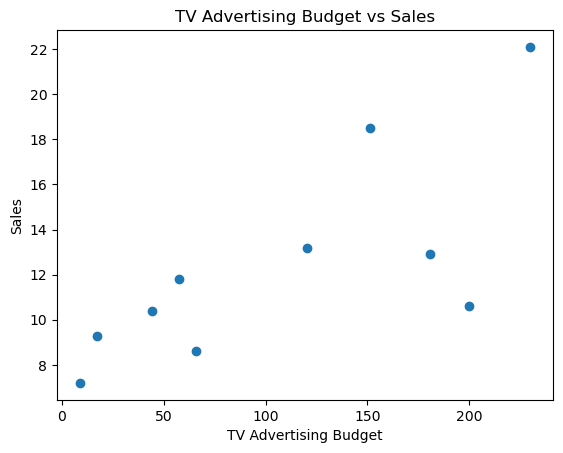

In [6]:
plt.scatter(df["TV"], df["Sales"])
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")
plt.title("TV Advertising Budget vs Sales")
plt.show()

## Data Preprocessing

In this dataset:
- There are no missing values
- All features are numerical
- Features are already scaled

Now we will separate input features and target column.

In [7]:
X = df.drop("Sales", axis=1)
y = df["Sales"]

X.head()

,TV,Radio,Newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4


## Train-Test Split

We will divide the dataset into:

- 80% training data
- 20% testing data

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (8, 3)
Testing Data: (2, 3)


## Model Building

Now we will create the Ridge Regression model.

Alpha is the regularization parameter.  
Higher alpha means stronger regularization.

In [9]:
ridge_model = Ridge(alpha=1.0)

## Model Training

Now we will train the Ridge Regression model using training data.

In [10]:
ridge_model.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


## Model Prediction

Now we will predict sales using the testing dataset.

In [11]:
y_pred = ridge_model.predict(X_test)

y_pred[:10]

array([15.95783055, 10.80021659])

## Model Evaluation

We will evaluate Ridge Regression using:

- MAE
- MSE
- RMSE
- R² Score

In [12]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R2 Score:", r2)

MAE: 2.8790235717994515
MSE: 14.433260756172976
RMSE: 3.7991131539048655
R2 Score: -1442.3260756173079


## Result Interpretation

Ridge Regression helps reduce overfitting by adding regularization.

If the R² score is closer to 1, the model is performing well.  
If the RMSE value is lower, the model predictions are better.

In [13]:
result = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

result.head(10)

,Actual,Predicted
8,10.6,15.957831
1,10.4,10.800217


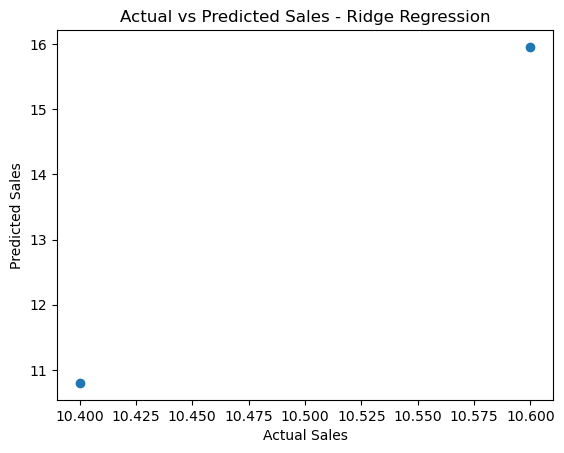

In [14]:
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales - Ridge Regression")
plt.show()

## Conclusion

In this notebook, we successfully implemented Ridge Regression using Python.

We performed:
- Dataset loading
- EDA
- Data preprocessing
- Train-test split
- Model building
- Model training
- Model evaluation

Ridge Regression is useful for predicting continuous values such as sales, profit, demand, and business revenue while reducing overfitting.